In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
import seaborn as sns

In [10]:
tips=sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Heat Map

In [35]:
numeric_data=tips.select_dtypes(include=['number'])

corr=numeric_data.corr()
corr


,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


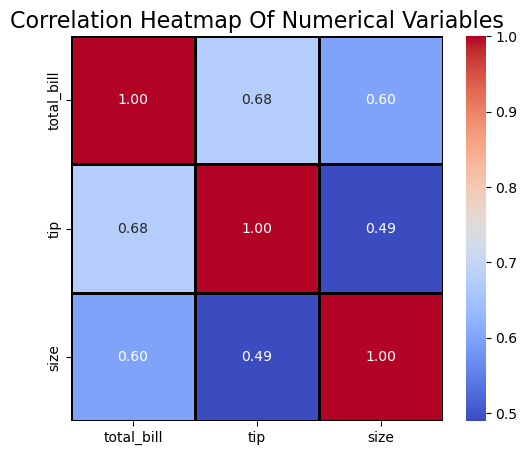

In [14]:
plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidth=1,
    linecolor="black",
    fmt=".2f"
)
plt.title("Correlation Heatmap Of Numerical Variables",fontsize=16)
plt.show()

## Count Plot

shows the count of observations in each category 

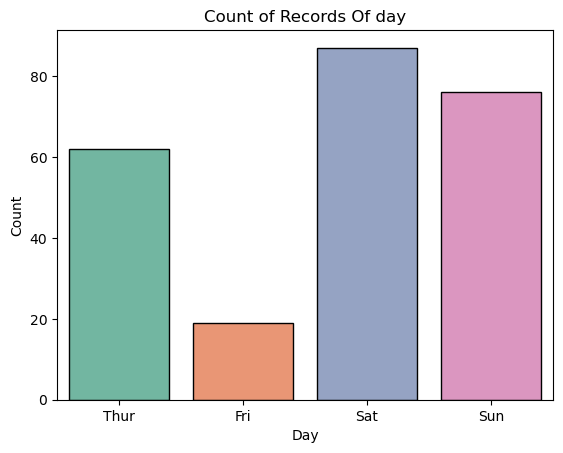

In [16]:
sns.countplot(x='day',data=tips,palette="Set2",edgecolor="black")
plt.title("Count of Records Of day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()

## Boxen Plot

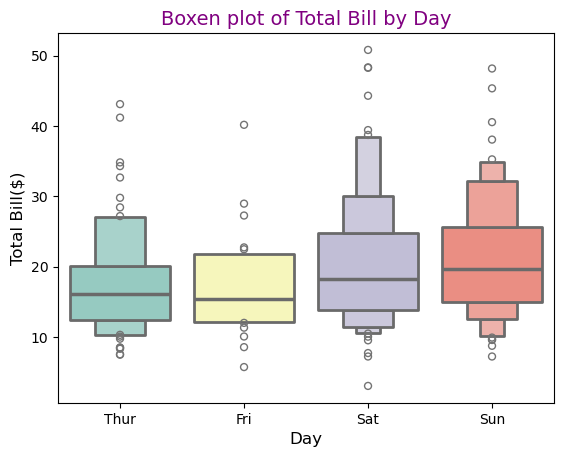

In [18]:
sns.boxenplot(
    x="day",
    y="total_bill",
    data=tips,
    palette="Set3",
    linewidth=2
)
plt.title("Boxen plot of Total Bill by Day",fontsize=14,color="purple")
plt.xlabel("Day",fontsize=12)
plt.ylabel("Total Bill($)",fontsize=12)
plt.show()

## Stacked Bar Plor

In [20]:
stack_data=tips.groupby(['day','sex'])['tip'].count().unstack()
stack_data

#unstack()--->Turn sex column into separate columns
#result--->rows=day,columns=sex,values=total tips

sex,Male,Female
day,,
Thur,30,32
Fri,10,9
Sat,59,28
Sun,58,18


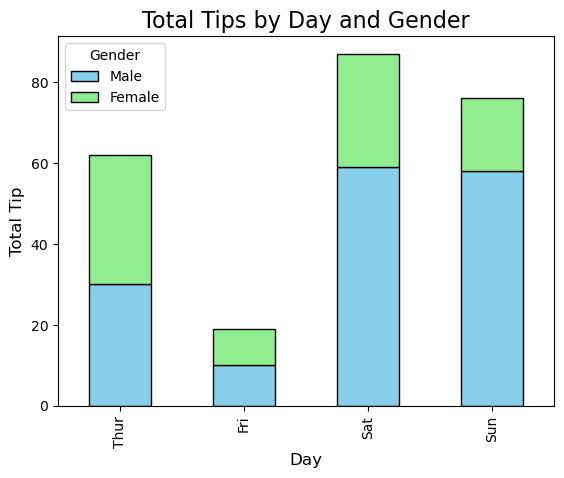

In [21]:
stack_data.plot(
    kind='bar',#barplot
    stacked=True, #stacked
    color=["skyblue","lightgreen"],#colors for male and female
    edgecolor="black"
)
plt.title("Total Tips by Day and Gender",fontsize=16)
plt.xlabel("Day",fontsize=12)
plt.ylabel("Total Tip",fontsize=12)
plt.legend(title="Gender")
plt.show()

## Sub Plot 

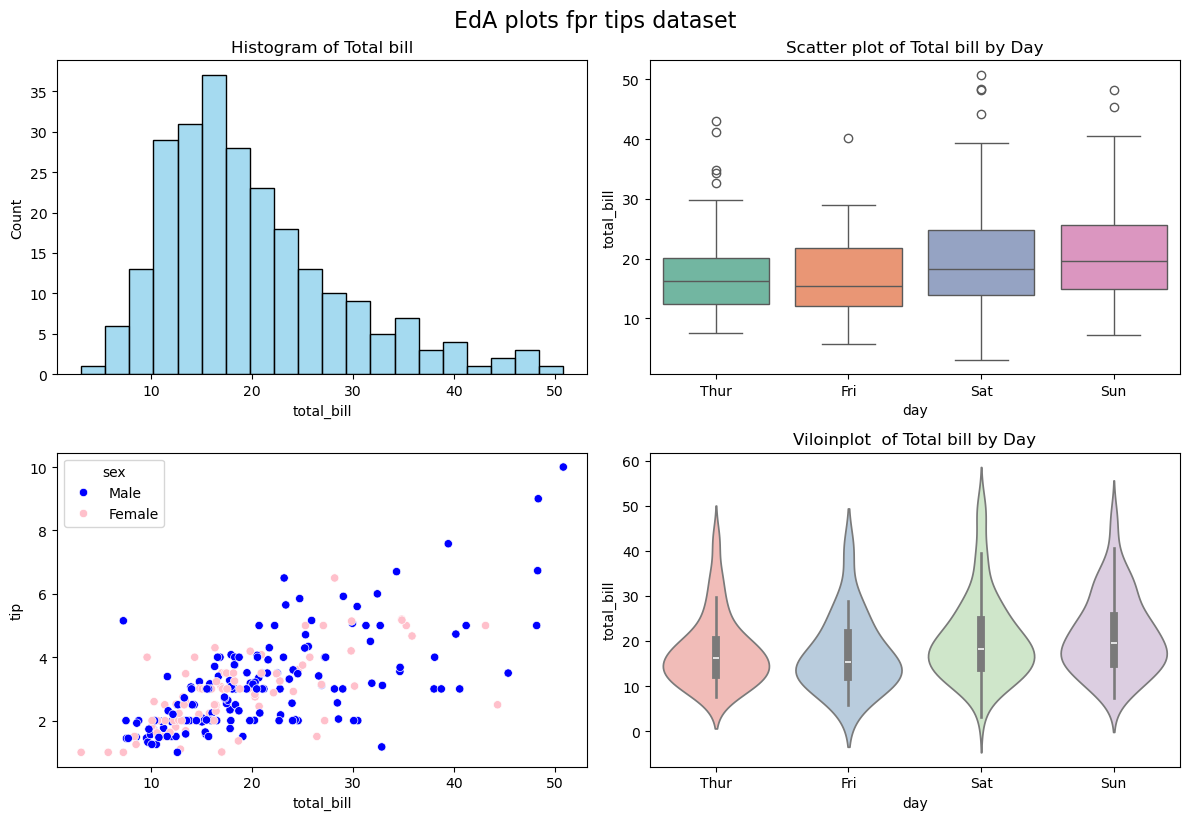

In [33]:
figs,axs=plt.subplots(2,2, figsize=(12,8))

#1.histogram of Total bill
sns.histplot(tips["total_bill"],bins=20,ax=axs[0,0],color="skyblue")
axs[0,0].set_title("Histogram of Total bill")


#2.boxplot of Total bill by day
sns.boxplot(x="day",y="total_bill",data=tips,ax=axs[0,1],palette="Set2")
axs[0,1].set_title("Boxplot of Total bill by Day")

#3.scaterplot of Total bill by day
sns.scatterplot(x="total_bill",y="tip",data=tips,ax=axs[1,0],hue="sex",palette=["blue","pink"])
axs[0,1].set_title("Scatter plot of Total bill by Day")

#2.violinplot of Total bill by day
sns.violinplot(x="day",y="total_bill",data=tips,ax=axs[1,1],palette="Pastel1")
axs[1,1].set_title("Viloinplot  of Total bill by Day")

plt.tight_layout()
plt.suptitle("EdA plots fpr tips dataset",fontsize=16,y=1.02)
plt.show()